# Exploring convutional layers through data

## Nicolás Toro Criollo

---

### Introducción

BLA BLA BLA [Cambiarlo]

### 0. Setup and imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix

# De una vez fijamos la semilla para que los resultados sean comparables
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Dataset Selection and Justification

For this assignment, I selected **CIFAR-10**, restricted to a vehicle-related subset of 4 classes: airplane, automobile, ship, and truck.

CIFAR-10 is a good fit for a convolutional architecture for a few reasons:

- It is image-based (32x32 RGB, 3 channels), which satisfies the assignment's dataset constraints.
- It is small enough to fit in memory on a laptop or a standard cloud notebook instance, so training does not require special hardware.
- Compared to datasets like MNIST, CIFAR-10 images have real backgrounds, variable lighting, and different object poses.
- These classes still have enough visual diversity (different shapes, backgrounds, and viewpoints).
- At the same time, they share some common local patterns (edges, wheels, hulls, wings, metallic textures) that a convolutional layer is specifically designed to detect through local receptive fields and weight sharing.

## 2. EDA (Exploraory Data Analysis)

Anlyzind the dataset, we can see that it gice us 10 classes, but we will only use 4 of them, which are the ones related to vehicles. The classes are: airplane, automobile, ship, and truck. We filtered the dataset to only use these classes.

The original dataset labels for these classes are not consecutive, so we will remap them to a new set of labels: 0 for airplane, 1 for automobile, 2 for ship, and 3 for truck. This is necessary because the output layer of the models will have 4 units, one per selected class.

### Loading the dataset and remapping the labels

In [12]:
# Indices de las clases de CIFAR-10 (según lo definido por el dataset) que corresponden a vehículos
VEHICLE_CLASSES = {0: "airplane", 1: "automobile", 8: "ship", 9: "truck"}
vehicle_ids_original = sorted(VEHICLE_CLASSES.keys())  # [0, 1, 8, 9]


# Cargar el dataset completo de CIFAR-10
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# Para facilitar el filtrado, aplanamos y_train_full/y_test_full de (N, 1) a (N,)
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

# Se construye una máscara para mantener solo las clases de vehículos
train_mask = np.isin(y_train_full, vehicle_ids_original)
test_mask = np.isin(y_test_full, vehicle_ids_original)

X_train_raw = X_train_full[train_mask]
y_train_raw = y_train_full[train_mask]
X_test_raw = X_test_full[test_mask]
y_test_raw = y_test_full[test_mask]

# Remapear las etiquetas originales {0,1,8,9} a etiquetas consecutivas {0,1,2,3}
label_map = {orig: new for new, orig in enumerate(vehicle_ids_original)}
class_names = [VEHICLE_CLASSES[orig] for orig in vehicle_ids_original]

y_train = np.array([label_map[label] for label in y_train_raw])
y_test = np.array([label_map[label] for label in y_test_raw])

print("X_train_raw shape:", X_train_raw.shape)
print("y_train shape:", y_train.shape)
print("X_test_raw shape:", X_test_raw.shape)
print("y_test shape:", y_test.shape)
print("Class names (index order):", class_names)

X_train_raw shape: (20000, 32, 32, 3)
y_train shape: (20000,)
X_test_raw shape: (4000, 32, 32, 3)
y_test shape: (4000,)
Class names (index order): ['airplane', 'automobile', 'ship', 'truck']


### Dataset size and class distribution
Before training the model, it is very importatn to check the classes are balanced. If one class has many samples than the others, the model could reach a high accuracy just by favoring that class, without learning useful patterns.

Total training samples: 20000
Total test samples: 4000

 class_id class_name  count split
        0   airplane   5000 train
        1 automobile   5000 train
        2       ship   5000 train
        3      truck   5000 train

 class_id class_name  count split
        0   airplane   1000  test
        1 automobile   1000  test
        2       ship   1000  test
        3      truck   1000  test


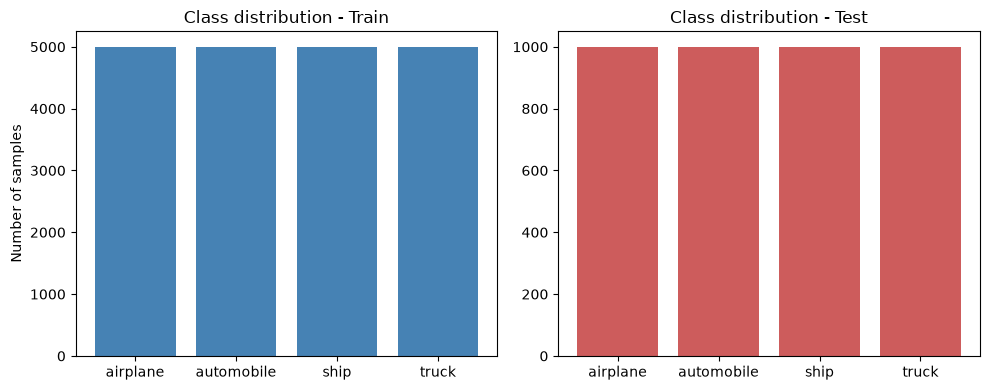

In [13]:
import pandas as pd

def class_distribution(y, class_names, split_name):
    counts = pd.Series(y).value_counts().sort_index()
    df = pd.DataFrame({
        "class_id": counts.index,
        "class_name": [class_names[i] for i in counts.index],
        "count": counts.values
    })
    df["split"] = split_name
    return df

train_dist = class_distribution(y_train, class_names, "train")
test_dist = class_distribution(y_test, class_names, "test")

print("Total training samples:", len(y_train))
print("Total test samples:", len(y_test))
print()
print(train_dist.to_string(index=False))
print()
print(test_dist.to_string(index=False))

# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(train_dist["class_name"], train_dist["count"], color="steelblue")
axes[0].set_title("Class distribution - Train")
axes[0].set_ylabel("Number of samples")

axes[1].bar(test_dist["class_name"], test_dist["count"], color="indianred")
axes[1].set_title("Class distribution - Test")

plt.tight_layout()
plt.show()

### Image dimensions and channels
Each image in te dataset is expected to be 32x32 pixels with 3 colors channels (RGB). This is important to check, because the input layer of the models will expect this shape. Besides, we are going to check the raw pixel value range.

In [14]:
sample_shape = X_train_raw[0].shape
height, width, channels = sample_shape

print("Sample image shape:", sample_shape)
print("Height:", height)
print("Width:", width)
print("Channels:", channels)

all_same_shape = all(img.shape == sample_shape for img in X_train_raw) and all(img.shape == sample_shape for img in X_test_raw)
print("All images have the same shape:", all_same_shape)

Sample image shape: (32, 32, 3)
Height: 32
Width: 32
Channels: 3
All images have the same shape: True


### Visualization

Creating a CCN model, looking at real examples before training is important to understand the data and the problem we are trying to solve. We will visualize a few samples from each class, along with their labels.

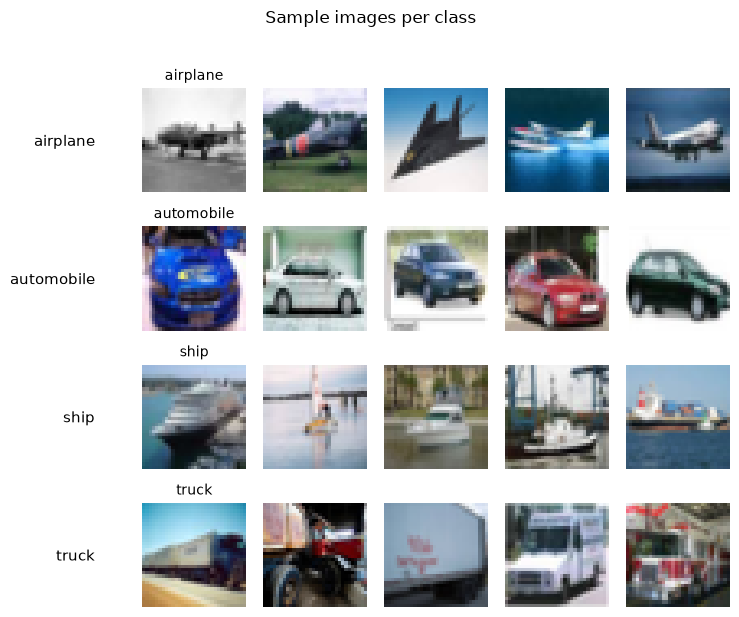

In [15]:
def plot_samples_per_class(X, y, class_names, samples_per_class=5):
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, samples_per_class, figsize=(samples_per_class * 1.5, n_classes * 1.5))
    
    for class_id, class_name in enumerate(class_names):
        class_indices = np.where(y == class_id)[0]
        chosen = np.random.choice(class_indices, samples_per_class, replace=False)

        for col, idx in enumerate(chosen):
            ax = axes[class_id, col]
            ax.imshow(X[idx])
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(class_name, fontsize=10)

        axes[class_id, 0].set_title(class_name, fontsize=10)

    # Se agrega una clase manuelmente para mostrar el nombre de la clase al lado izquierdo de cada fila
    for class_id, class_name in enumerate(class_names):
        axes[class_id, 0].text(-15, 16, class_name, fontsize=11, va="center", ha="right")

    plt.suptitle("Sample images per class", y=1.02)
    plt.tight_layout()
    plt.show()

np.random.seed(SEED)
plot_samples_per_class(X_train_raw, y_train, class_names, samples_per_class=5)

### Prepocessing needed

Based on the exploration above, the following preprocessing steps are needed:

- Normalize the pixel values to the range [0, 1]
- Flatten the images for the baseline model, but keep them in 3D for the CNN model
- Train/test split is already provided by the dataset, so we will use that.
- No resizing is needed, since the images are already 32x32 pixels.

### 3. Baselin no-convolutional (Flatten + Dense)

### 4. CNN architecture design

### 5. Controlled experiment on the convolutional layer

### 6. Interpretation and architectural reasoning

### 7. Training and deplyment on Sagemaker

### 8. Conclusions